In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import KFold

In [3]:
df = pd.read_excel(fr"processed_heart_data.xlsx")

x = df.drop('disease_present', axis=1)
y = df['disease_present']

## Initial Model Creation

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
train_start = time.perf_counter()
knn_model = KNeighborsClassifier()   # default n_neighbors=5
knn_model.fit(x_train, y_train)
train_time = time.perf_counter() - train_start
print(f"Training Time: {train_time:.6f} seconds")

Training Time: 0.002470 seconds


In [10]:
predict_start = time.perf_counter()
y_pred = knn_model.predict(x_test)
predict_time = time.perf_counter() - predict_start
print(f"Prediction Time: {predict_time:.6f} seconds")

Prediction Time: 0.314814 seconds


In [12]:
print(f"Accuracy Score: {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall Score: {metrics.recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {metrics.f1_score(y_test, y_pred):.4f}")

Accuracy Score: 0.6393
Precision Score: 0.6786
Recall Score: 0.5938
F1 Score: 0.6333


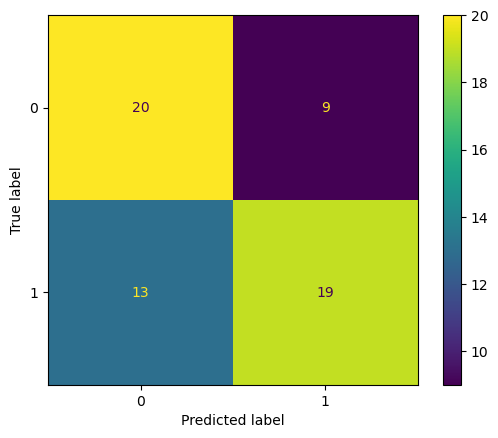

In [14]:
cm = metrics.confusion_matrix(y_test, y_pred, labels=knn_model.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot()

## Testing different number of neighbors

In [24]:
# Define the range of neighbors to test
neighbors_range = range(1, 22, 2)   # odd numbers from 1 to 21

# Store results
knn_results = []

print("Evaluating KNN with different n_neighbors values on test set:")
print("-" * 80)
print(f"{'k':>2} | {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6} | {'Composite':>9} | {'Train(s)':>8} {'Pred(s)':>8}")
print("-" * 80)

for k in neighbors_range:
    # Train model
    train_start = time.perf_counter()
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    train_time = time.perf_counter() - train_start
    
    # Predict and get probabilities for AUC
    predict_start = time.perf_counter()
    y_pred = knn.predict(x_test)
    y_pred_proba = knn.predict_proba(x_test)[:, 1]   # probability of positive class
    predict_time = time.perf_counter() - predict_start
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Composite score: average of all five metrics (equal weight)
    composite = (acc + prec + rec + f1 + auc) / 5
    
    # Store
    knn_results.append({
        'n_neighbors': k,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': auc,
        'composite': composite,
        'train_time': train_time,
        'predict_time': predict_time
    })
    
    print(f"{k:2d} | {acc:6.4f} {prec:6.4f} {rec:6.4f} {f1:6.4f} {auc:6.4f} | {composite:9.4f} | {train_time:8.6f} {predict_time:8.6f}")

Evaluating KNN with different n_neighbors values on test set:
--------------------------------------------------------------------------------
 k |    Acc   Prec    Rec     F1    AUC | Composite | Train(s)  Pred(s)
--------------------------------------------------------------------------------
 1 | 0.6230 0.6552 0.5938 0.6230 0.6245 |    0.6239 | 0.003384 0.010226
 3 | 0.6557 0.6774 0.6562 0.6667 0.6821 |    0.6676 | 0.001288 0.010071
 5 | 0.6393 0.6786 0.5938 0.6333 0.6816 |    0.6453 | 0.002222 0.011323
 7 | 0.6230 0.6452 0.6250 0.6349 0.6827 |    0.6421 | 0.002410 0.011003
 9 | 0.6393 0.6562 0.6562 0.6562 0.7053 |    0.6627 | 0.001452 0.012465
11 | 0.6885 0.7600 0.5938 0.6667 0.7166 |    0.6851 | 0.001389 0.009386
13 | 0.7213 0.8261 0.5938 0.6909 0.7484 |    0.7161 | 0.001227 0.009726
15 | 0.6885 0.7600 0.5938 0.6667 0.7629 |    0.6944 | 0.001345 0.009530
17 | 0.7049 0.7917 0.5938 0.6786 0.7586 |    0.7055 | 0.001314 0.009530
19 | 0.7213 0.8000 0.6250 0.7018 0.7602 |    0.7217 | 0.

In [28]:
# Convert to DataFrame
knn_results_df = pd.DataFrame(knn_results)

# Find best overall model (highest composite score)
best_idx = knn_results_df['composite'].idxmax()
best_model = knn_results_df.loc[best_idx]

print("\n" + "=" * 80)
print("Best Overall KNN n_neighbors (based on composite score = average of Acc, Prec, Rec, F1, AUC)")
print("=" * 80)
print(f"  n_neighbors = {int(best_model['n_neighbors'])}")
print(f"  Accuracy:    {best_model['accuracy']:.4f}")
print(f"  Precision:   {best_model['precision']:.4f}")
print(f"  Recall:      {best_model['recall']:.4f}")
print(f"  F1-Score:    {best_model['f1_score']:.4f}")
print(f"  ROC-AUC:     {best_model['roc_auc']:.4f}")
print(f"  Composite score: {best_model['composite']:.4f}")
print(f"  Training time:   {best_model['train_time']:.6f} seconds")
print(f"  Prediction time: {best_model['predict_time']:.6f} seconds")
print("=" * 80)


Best Overall KNN n_neighbors (based on composite score = average of Acc, Prec, Rec, F1, AUC)
  n_neighbors = 19
  Accuracy:    0.7213
  Precision:   0.8000
  Recall:      0.6250
  F1-Score:    0.7018
  ROC-AUC:     0.7602
  Composite score: 0.7217
  Training time:   0.001371 seconds
  Prediction time: 0.009837 seconds


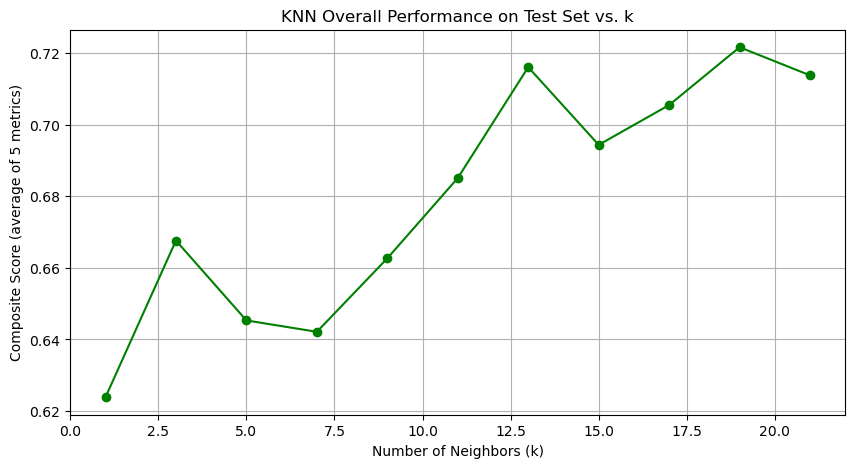

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(knn_results_df['n_neighbors'], knn_results_df['composite'], marker='o', linestyle='-', color='green')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Composite Score (average of 5 metrics)')
plt.title('KNN Overall Performance on Test Set vs. k')
plt.grid(True)
plt.show()

## Five fold cross validation for best KNN neighbor number

In [32]:
best_k_value = int(best_k['n_neighbors'])
print(f"Running 5-fold CV with optimal k={best_k_value}")

k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

best_knn_fold_results = []
best_knn_fold_times = []

fold_num = 1
for train_index, val_index in kf.split(x):
    x_train_fold, x_val_fold = x.iloc[train_index], x.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    
    train_start = time.perf_counter()
    knn_opt = KNeighborsClassifier(n_neighbors=best_k_value)
    knn_opt.fit(x_train_fold, y_train_fold)
    train_time = time.perf_counter() - train_start
    
    predict_start = time.perf_counter()
    y_pred_opt = knn_opt.predict(x_val_fold)
    y_pred_proba_opt = knn_opt.predict_proba(x_val_fold)[:, 1]
    predict_time = time.perf_counter() - predict_start
    
    acc = accuracy_score(y_val_fold, y_pred_opt)
    prec = precision_score(y_val_fold, y_pred_opt, zero_division=0)
    rec = recall_score(y_val_fold, y_pred_opt, zero_division=0)
    f1 = f1_score(y_val_fold, y_pred_opt, zero_division=0)
    auc = roc_auc_score(y_val_fold, y_pred_proba_opt)
    
    best_knn_fold_results.append({
        'fold': fold_num,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': auc
    })
    best_knn_fold_times.append({
        'fold': fold_num,
        'train_time': train_time,
        'predict_time': predict_time,
        'total_time': train_time + predict_time
    })
    
    print(f"Fold {fold_num}: Acc={acc:.4f}, F1={f1:.4f}, Time={train_time+predict_time:.6f}s")
    fold_num += 1

best_knn_cv_df = pd.DataFrame(best_knn_fold_results)
print("\nSummary for optimal k={}:".format(best_k_value))
print(f"  Accuracy:  {best_knn_cv_df['accuracy'].mean():.4f} ± {best_knn_cv_df['accuracy'].std():.4f}")
print(f"  F1-Score:  {best_knn_cv_df['f1_score'].mean():.4f} ± {best_knn_cv_df['f1_score'].std():.4f}")

Running 5-fold CV with optimal k=19
Fold 1: Acc=0.7213, F1=0.7018, Time=0.014309s
Fold 2: Acc=0.6393, F1=0.6071, Time=0.011463s
Fold 3: Acc=0.6557, F1=0.5333, Time=0.012366s
Fold 4: Acc=0.6833, F1=0.6885, Time=0.017326s
Fold 5: Acc=0.6333, F1=0.5769, Time=0.010940s

Summary for optimal k=19:
  Accuracy:  0.6666 ± 0.0362
  F1-Score:  0.6215 ± 0.0723
